## Land Type Classification using Sentinel-2 Satellite Images

## Import Libraries

In [19]:
import warnings
warnings.filterwarnings('ignore')

# Import all functions from Orignal_Functions
from Orignal_Functions import *

# Set style
setup_visualization_style()

# Milestone 1: EDA and Data Preprocessing

## 1. Dataset Configuration

In [20]:
# Get dataset configuration
LAND_TYPES, SENTINEL2_BANDS = get_dataset_configuration()

# Setup directories
MILESTONE_DIR = Path("./")
DATA_DIR = MILESTONE_DIR / "processed_data"
VISUALIZATIONS_DIR = MILESTONE_DIR / "visualizations"
BASE_DIR = Path("milestone1/Balanced data")

DATA_DIR, VISUALIZATIONS_DIR = setup_directories(DATA_DIR, VISUALIZATIONS_DIR)

print(f"✓ Configuration loaded")
print(f"✓ Land types: {len(LAND_TYPES)} classes")
print(f"✓ Sentinel-2 bands: {len(SENTINEL2_BANDS)} bands")

✓ Configuration loaded
✓ Land types: 10 classes
✓ Sentinel-2 bands: 12 bands


## 2. Load Sample Images and Analyze Band Structure

In [21]:
# Load sample images and analyze
sample_images, sample_metadata = load_sample_images_per_class(BASE_DIR, LAND_TYPES)

# Analyze one sample image
sample_data = sample_images['Forest']
analyze_sample_image(sample_data)

Sample image shape (bands, height, width): (13, 64, 64)
Data type: uint16
Value range: 7-5087

Band statistics for sample image:
  Band 1: Mean=1149.48, Std=4.61
  Band 2: Mean=831.31, Std=18.45
  Band 3: Mean=652.27, Std=41.53
  Band 4: Mean=410.17, Std=35.01
  Band 5: Mean=659.03, Std=67.90
  Band 6: Mean=1998.10, Std=339.98
  Band 7: Mean=2707.45, Std=519.51
  Band 8: Mean=2612.36, Std=625.29
  Band 9: Mean=579.30, Std=87.73
  Band 10: Mean=8.45, Std=0.75
  Band 11: Mean=1304.69, Std=237.92
  Band 12: Mean=496.32, Std=87.56


## 3. Visualize Sample Images and RGB Composites

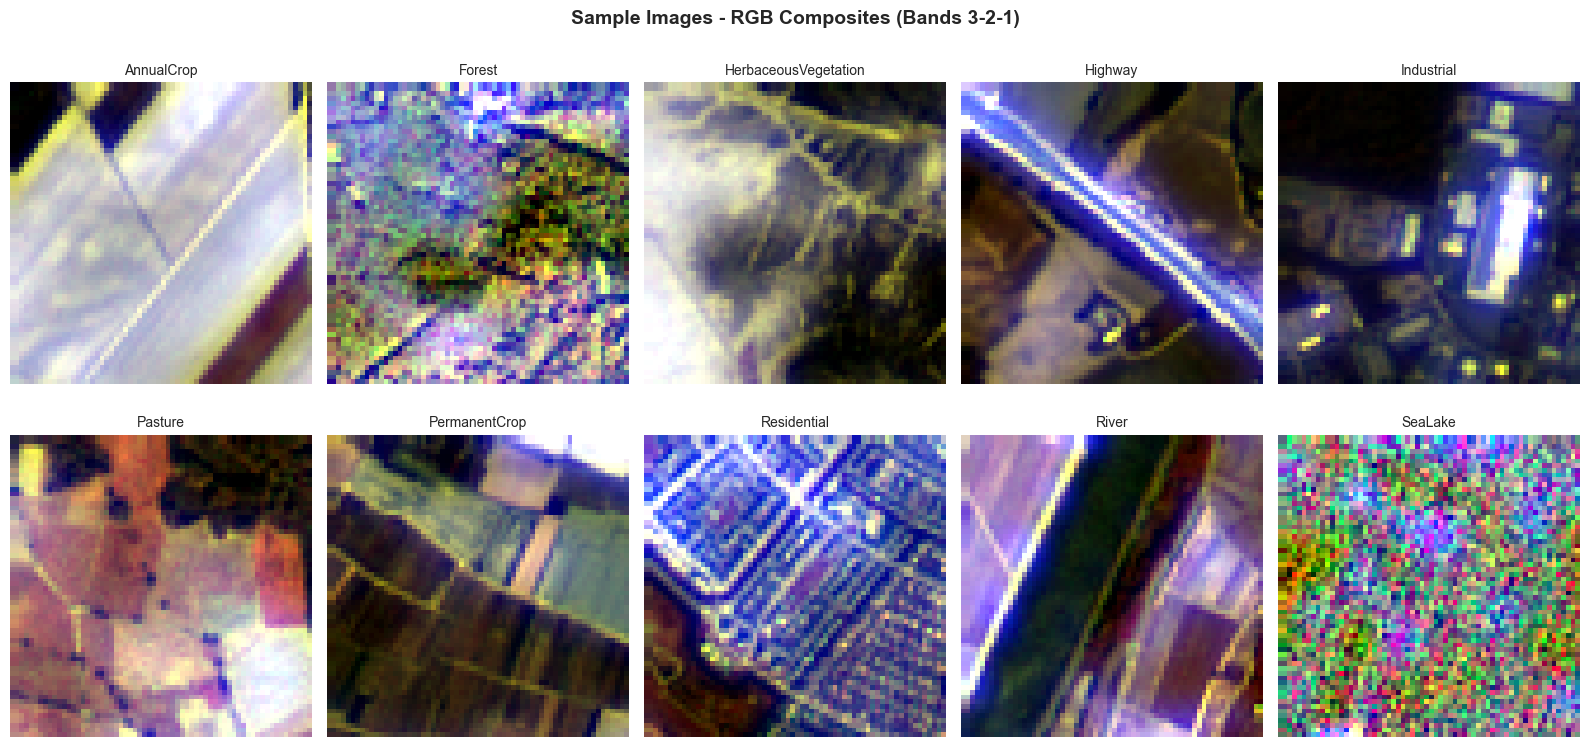

✓ RGB composite visualization saved!


In [22]:
# Visualize RGB composites
visualize_rgb_composites(sample_images, LAND_TYPES, VISUALIZATIONS_DIR)

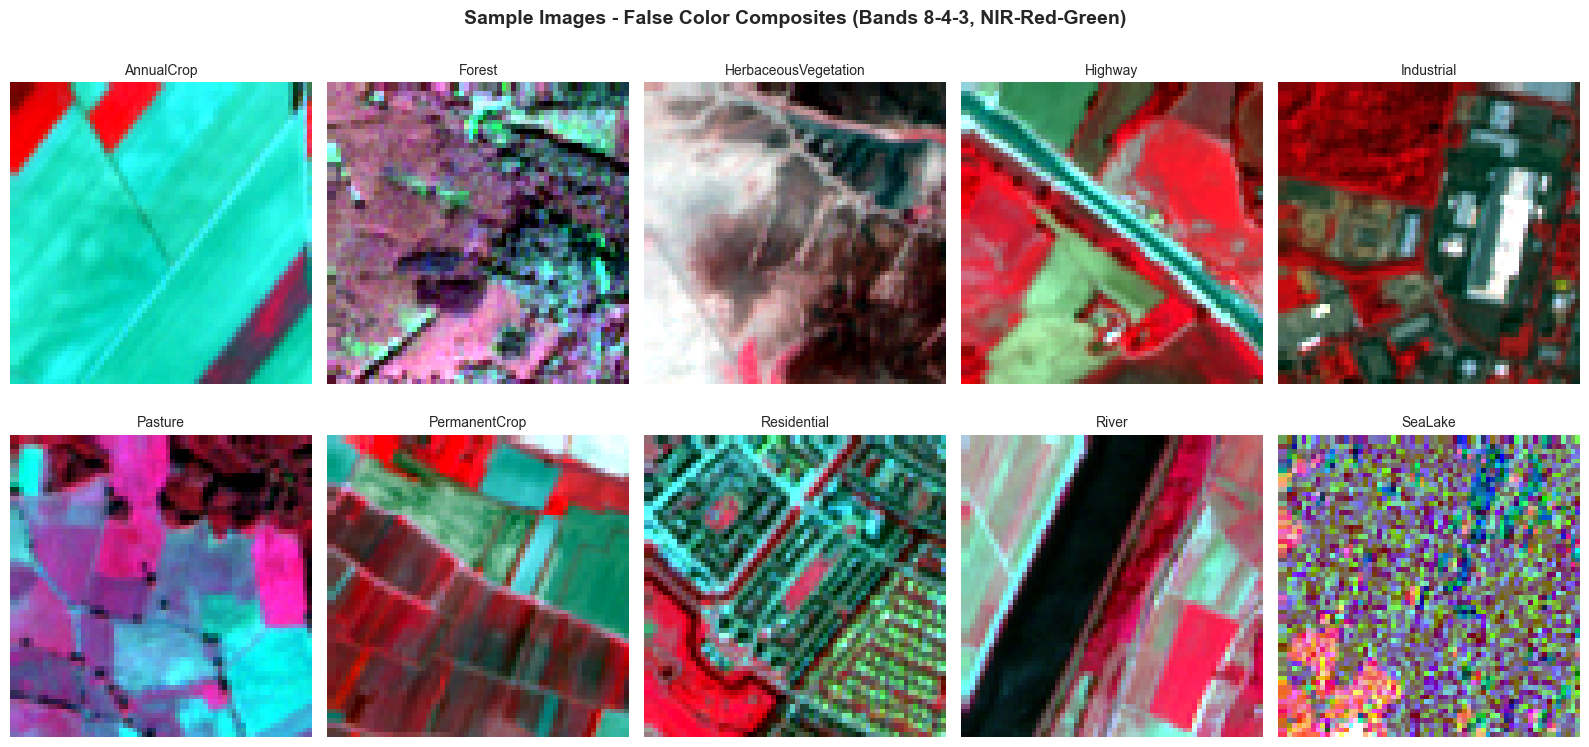

✓ False color composite visualization saved!


In [23]:
# Visualize False Color composites
visualize_false_color_composites(sample_images, LAND_TYPES, VISUALIZATIONS_DIR)

## 4. Calculate Vegetation Indices

In [24]:
# Calculate vegetation indices for sample images
ndvi_samples = {}
ndbi_samples = {}
ndwi_samples = {}

for land_type in LAND_TYPES:
    ndvi, ndbi, ndwi = calculate_vegetation_indices(sample_images[land_type])
    ndvi_samples[land_type] = ndvi
    ndbi_samples[land_type] = ndbi
    ndwi_samples[land_type] = ndwi

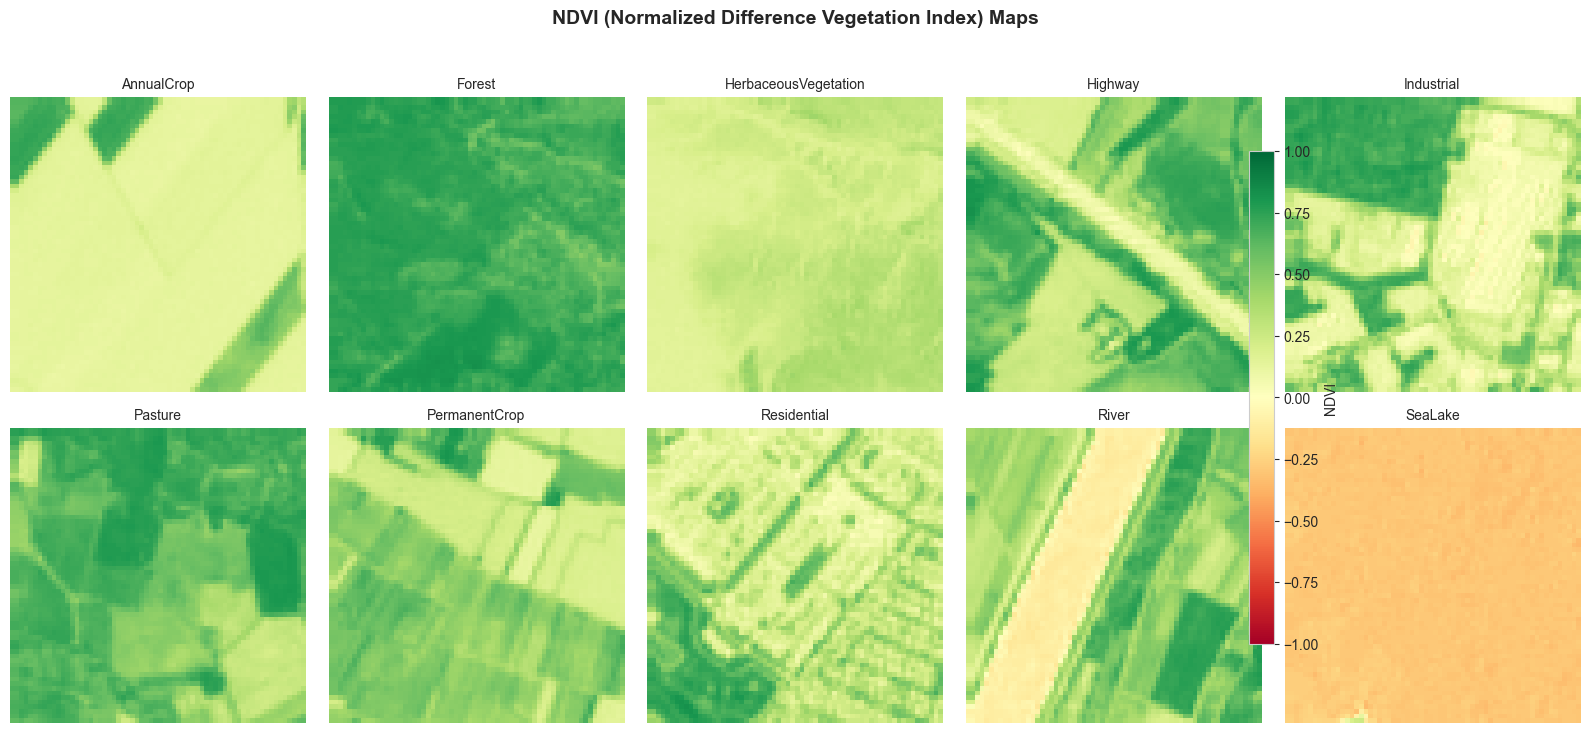

✓ NDVI visualization saved!


In [25]:
# Visualize NDVI maps
visualize_ndvi_maps(ndvi_samples, LAND_TYPES, VISUALIZATIONS_DIR)

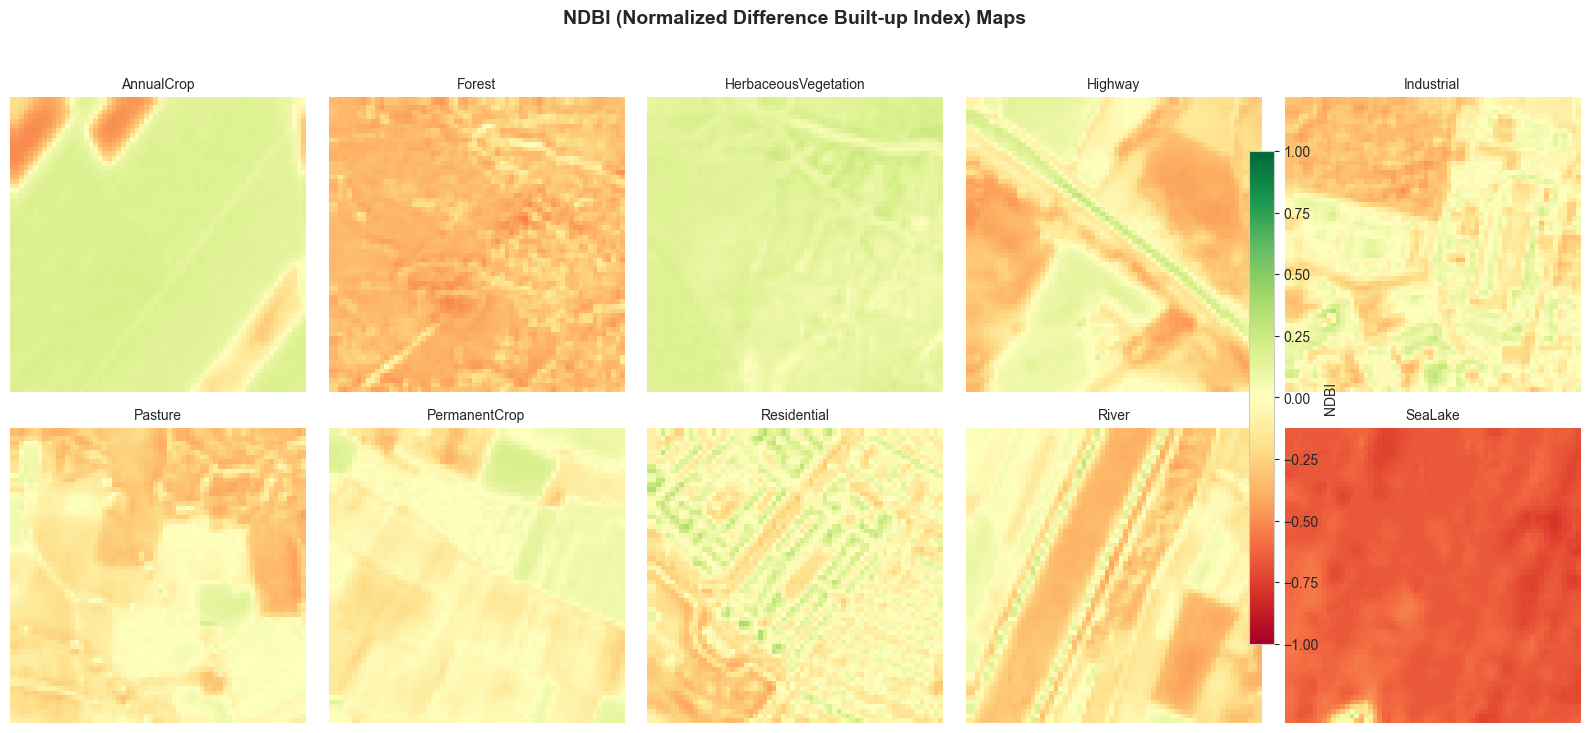

✓ NDBI visualization saved!


In [26]:
# Visualize NDBI maps
visualize_ndbi_maps(ndbi_samples, LAND_TYPES, VISUALIZATIONS_DIR)

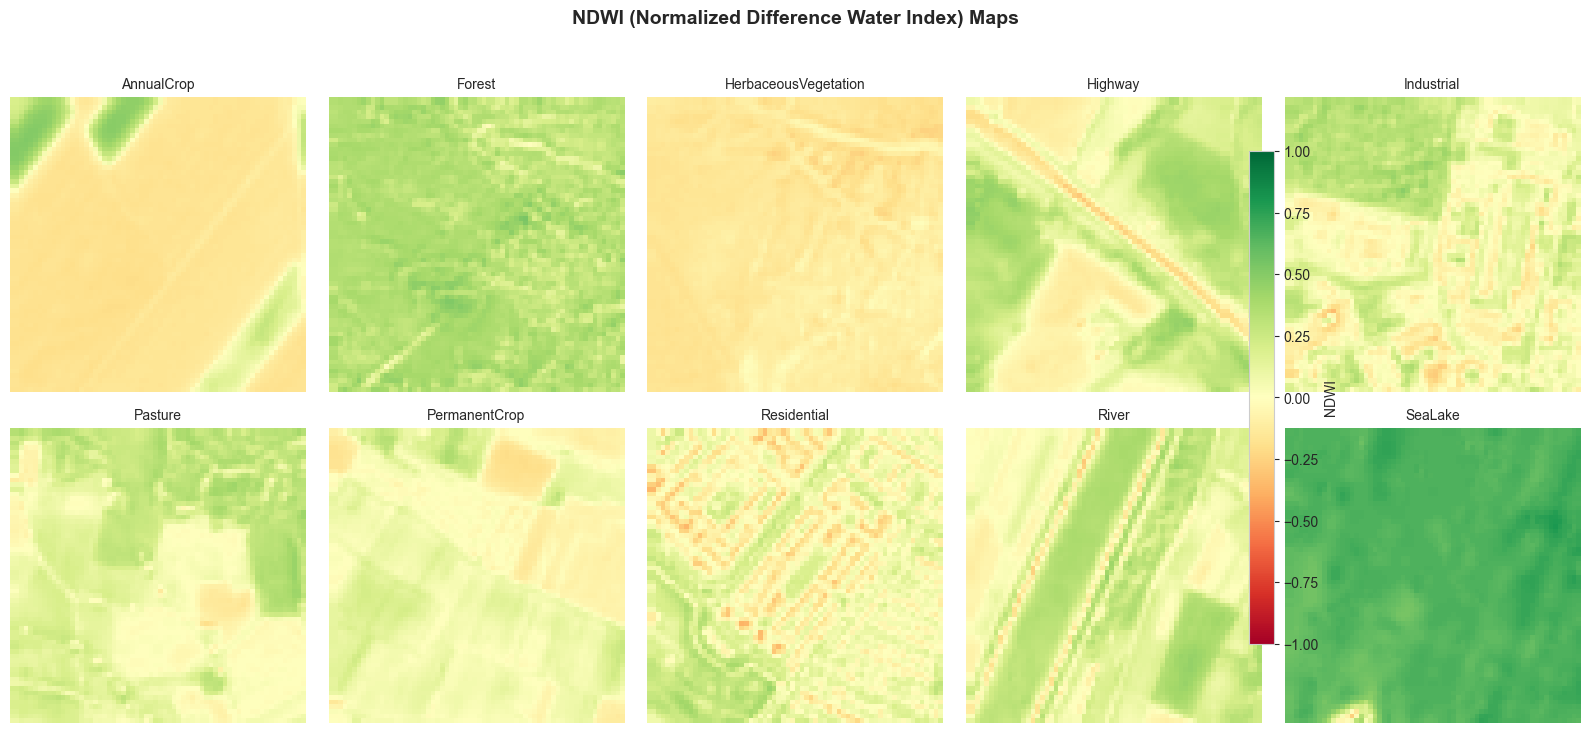

✓ NDWI visualization saved!


In [27]:
# Visualize NDWI maps
visualize_ndwi_maps(ndwi_samples, LAND_TYPES, VISUALIZATIONS_DIR)

## 5. Spectral Signature Analysis

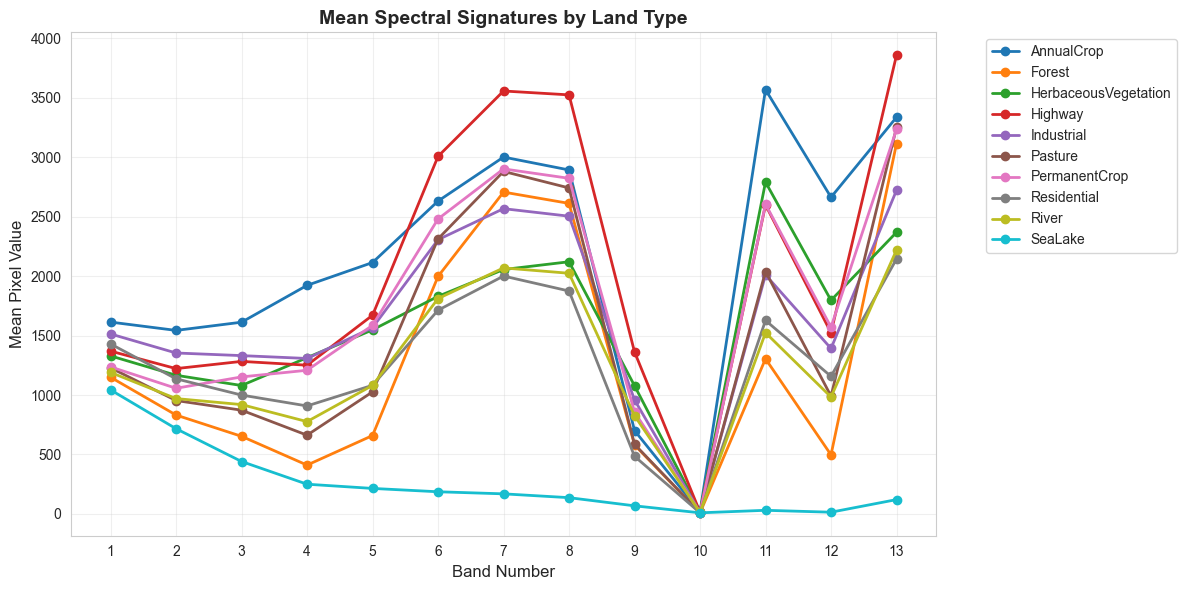

✓ Spectral signature plot saved!


In [28]:
# Calculate and visualize spectral signatures
spectral_signatures = calculate_spectral_signatures(sample_images, LAND_TYPES)
visualize_spectral_signatures(spectral_signatures, LAND_TYPES, VISUALIZATIONS_DIR)

## 6. Preprocessing and Normalization

In [29]:
# Load all images from balanced dataset
print("Loading all images from balanced dataset...")
all_images, all_labels, indices_data = load_all_images(BASE_DIR, LAND_TYPES)

print(f"\n✓ Total images loaded: {len(all_images)}")
print(f"✓ Total labels: {len(all_labels)}")
print(f"✓ Image shape: {all_images[0].shape}")

Loading all images from balanced dataset...


Loading SeaLake: 100%|██████████| 2000/2000 [00:12<00:00, 165.29it/s]



✓ Total images loaded: 20000
✓ Total labels: 20000
✓ Image shape: (13, 64, 64)


In [30]:
# Process all images
processed_images = process_all_images(all_images)
labels_array = np.array(all_labels)

print(f"\n✓ Processed images shape: {processed_images.shape}")
print(f"✓ Labels shape: {labels_array.shape}")

Preprocessing all images...


Preprocessing: 100%|██████████| 20000/20000 [01:01<00:00, 324.51it/s]



✓ Processed images shape: (20000, 13, 64, 64)
✓ Labels shape: (20000,)


## 7. Data Splitting (60% Train, 20% Val, 20% Test)

In [31]:
# Split data into train, validation, and test sets
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    processed_images, labels_array, test_size=0.2, val_ratio=0.25, random_state=42
)

# Print statistics
print_data_split_statistics(X_train, X_val, X_test, y_train, y_val, y_test, LAND_TYPES)

✓ Data Split Statistics:
   Total samples: 20,000
   Training set: 12,000 (60.0%)
   Validation set: 4,000 (20.0%)
   Test set: 4,000 (20.0%)

✓ Class distribution verified across all splits
   AnnualCrop: Train=1200, Val=400, Test=400
   Forest: Train=1200, Val=400, Test=400
   HerbaceousVegetation: Train=1200, Val=400, Test=400


In [32]:
# Save processed data to disk
save_processed_data(X_train, X_val, X_test, y_train, y_val, y_test, 
                   indices_data, all_labels, DATA_DIR, LAND_TYPES, SENTINEL2_BANDS)

✓ All data saved successfully!
   - metadata.json
   - vegetation_indices.csv
   - X_test.npy
   - X_train.npy
   - X_val.npy
   - y_test.npy
   - y_train.npy
   - y_val.npy


In [33]:
# Test: Load and display sample training data
data = np.load('processed_data/X_train.npy')
print("Training data shape:", data.shape)

Training data shape: (12000, 13, 64, 64)
